In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
under_expression = True

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False  # Independent toggle: include only ClinVar-annotated variants

# Initialize new annotation variable as None
new_anno_local = None

# Plot params parameters
max_gene_rank = 50   # compute up to this rank within each gene
ci_factor     = 1

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = f"Top N {vc['x_label']} variants"

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Categories: ['missense']
  X-label: Top N Missense variants
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""clinpred_score""","""#FFDC80""","""ClinPred""",1
"""missense""","""bayes_del""","""#FFBF00""","""BayesDel""",1
"""missense""","""polyphen""","""#FF90AA""","""PolyPhen2""",1
"""missense""","""revel_score""","""#FF7000""","""REVEL""",1
"""missense""","""am_pathogenicity""","""#E63946""","""AlphaMissense""",1
…,…,…,…,…
"""regulatory""","""fz_gtex_max""","""#9467BD""","""Flashzoi max across RNA (GTEx)""",1
"""regulatory""","""fz_all_min""","""#00A99D""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_all_max""","""#00A99D""","""Flashzoi max across RNA (all)""",1


In [3]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000131471""","""ENSG00000131471_olink""",0.16163,0.16163,1.0
"""ENSG00000143382""","""ENSG00000143382_olink""",0.154266,0.154266,1.0
"""ENSG00000099994""","""ENSG00000099994_olink""",0.148376,0.148376,1.0
"""ENSG00000213927""","""ENSG00000213927_olink""",0.147887,0.147887,1.0
"""ENSG00000174080""","""ENSG00000174080_olink""",0.147505,0.147505,1.0
…,…,…,…,…
"""ENSG00000168079""","""ENSG00000168079_olink""",0.002397,0.002397,1.0
"""ENSG00000149564""","""ENSG00000149564_olink""",0.001879,0.001879,1.0
"""ENSG00000141736""","""ENSG00000141736_olink""",0.0014,0.0014,1.0


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_GENCODEv39_260218_rep0.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_GENCODEv39_260218_rep0.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_354207/2818384784.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_gtex_min
str,str,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,-0.004409
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,-0.013746
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,-0.003757
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.003302
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,-0.004555
…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,-0.017778
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,-0.006965
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,-0.008397


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories is already set from YAML in the config cell
selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_354207/3121672973.py:62: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_354207/3121672973.py:71: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,esm1b_llr,polyphen,am_pathogenicity,bayes_del,clinpred_score,esmscoremissense,revel_score,id,cpt1_llr
str,f32,f32,f32,f32,f32,f32,f32,str,f32
"""ENSG00000132330""",-16.052999,0.999,0.9817,0.119158,0.995352,-15.721,0.532,"""chr2:238098246:C:A""",0.0
"""ENSG00000139540""",-8.171,0.983,0.1989,-0.356889,0.976118,-6.073,0.173,"""chr12:56237261:G:C""",0.287604
"""ENSG00000173531""",0.0,0.0,0.0,-0.404989,0.026855,-3.941,0.189,"""chr3:49685725:A:T""",0.0
"""ENSG00000173531""",0.0,0.0,0.0,-0.404989,0.026855,-3.941,0.189,"""chr3:49685725:A:T""",0.0
"""ENSG00000176105""",-11.93,0.726,0.8702,0.131296,0.962179,-6.762,0.691,"""chr18:732848:C:T""",0.285858
…,…,…,…,…,…,…,…,…,…
"""ENSG00000184530""",-3.294,0.995,0.6612,-0.092493,0.961089,-3.334,0.295,"""chr6:127590173:C:A""",0.21577
"""ENSG00000131471""",-7.932,1.0,0.2252,-0.098188,0.99814,-3.616,0.769,"""chr17:42851708:G:A""",0.53047
"""ENSG00000033170""",-4.037,0.908,0.1835,0.157283,0.946092,-5.216,0.629,"""chr14:65629559:G:A""",0.461837


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_354207/3954935598.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i32
"""chr10:123713521:C:A""","""ENSG00000121898""","""esmscoremissense""",1
"""chr10:123713311:C:A""","""ENSG00000121898""","""esmscoremissense""",1
"""chr19:8985604:G:A""","""ENSG00000181143""","""esmscoremissense""",1
"""chr1:65254644:C:A""","""ENSG00000116675""","""esmscoremissense""",1
"""chr12:68842313:C:T""","""ENSG00000135678""","""esmscoremissense""",1


In [14]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_354207/631692843.py:39: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr10:123862627:C:T""","""ENSG00000121898""","""clinpred_score""",0.992433,"""missense""",1,0.992433
"""chr12:3656395:C:A""","""ENSG00000130038""","""clinpred_score""",0.986734,"""missense""",1,0.986734
"""chr2:102232975:A:G""","""ENSG00000115598""","""clinpred_score""",0.998525,"""missense""",1,0.998525
"""chr3:50187913:G:A""","""ENSG00000001617""","""clinpred_score""",0.104261,"""missense""",1,0.104261
"""chr11:72228355:A:G""","""ENSG00000165458""","""clinpred_score""",0.90519,"""missense""",1,0.90519
…,…,…,…,…,…,…
"""chr3:78714430:T:C""","""ENSG00000169855""","""clinpred_score""",0.925146,"""missense""",1,0.925146
"""chr6:132755856:G:C""","""ENSG00000112303""","""clinpred_score""",0.978139,"""missense""",1,0.978139
"""chr4:159193234:G:A""","""ENSG00000109756""","""clinpred_score""",0.613683,"""missense""",1,0.613683


In [15]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


# Per-gene ranking: Nth variant sliding window

In [17]:
# Rank variants within each (annotation, gene) group using only variants
# that have phenotype data (i.e. survived the join with variant_zscores).
# This avoids the gap problem where globally top-ranked variants may have
# no phenotype data, leaving holes in the per-gene top-N.

# --- Re-ranking bootstrap: join variant z-scores with annotation ranks ---
id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink_whitelist
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# Negate so that "deleterious" variants always have positive z-scores
# (olink phenotype is naturally negative for LoF carriers)
variant_zscores = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value = pl.when(under_expression==True).then(-pl.col('mean_pheno_value')).otherwise(pl.col('mean_pheno_value'))
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

ranked_zscores_genewise = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor']),
        on=['id', 'region'],
        how='inner'
    )
    .with_columns(
        gene_rank = pl.col('annotation_score_dircor')
                      .rank(method='ordinal', descending=True)
                      .over(['annotation', 'region'])
                      .cast(pl.Int32)
    )
    .collect(engine='streaming')
)

ranked_zscores_genewise

Variant z-scores: 78598 variant-gene pairs


id,region,mean_pheno_value,annotation,annotation_score_dircor,gene_rank
str,str,f32,str,f32,i32
"""chr11:125981111:C:T""","""ENSG00000064309""",-0.058271,"""clinpred_score""",0.813438,59
"""chr19:41219427:C:T""","""ENSG00000167601""",-0.35679,"""clinpred_score""",0.015248,105
"""chr9:37432132:A:C""","""ENSG00000137106""",3.33104,"""clinpred_score""",0.99736,6
"""chr19:5693416:G:A""","""ENSG00000196365""",0.494775,"""clinpred_score""",0.995636,28
"""chr4:159343352:G:A""","""ENSG00000109756""",0.788447,"""clinpred_score""",0.139287,102
…,…,…,…,…,…
"""chr3:148844755:G:A""","""ENSG00000153002""",0.922997,"""clinpred_score""",0.866504,38
"""chr13:46084315:T:C""","""ENSG00000080618""",2.009476,"""clinpred_score""",0.236087,21
"""chr19:8956209:G:A""","""ENSG00000181143""",0.278317,"""clinpred_score""",0.130756,634


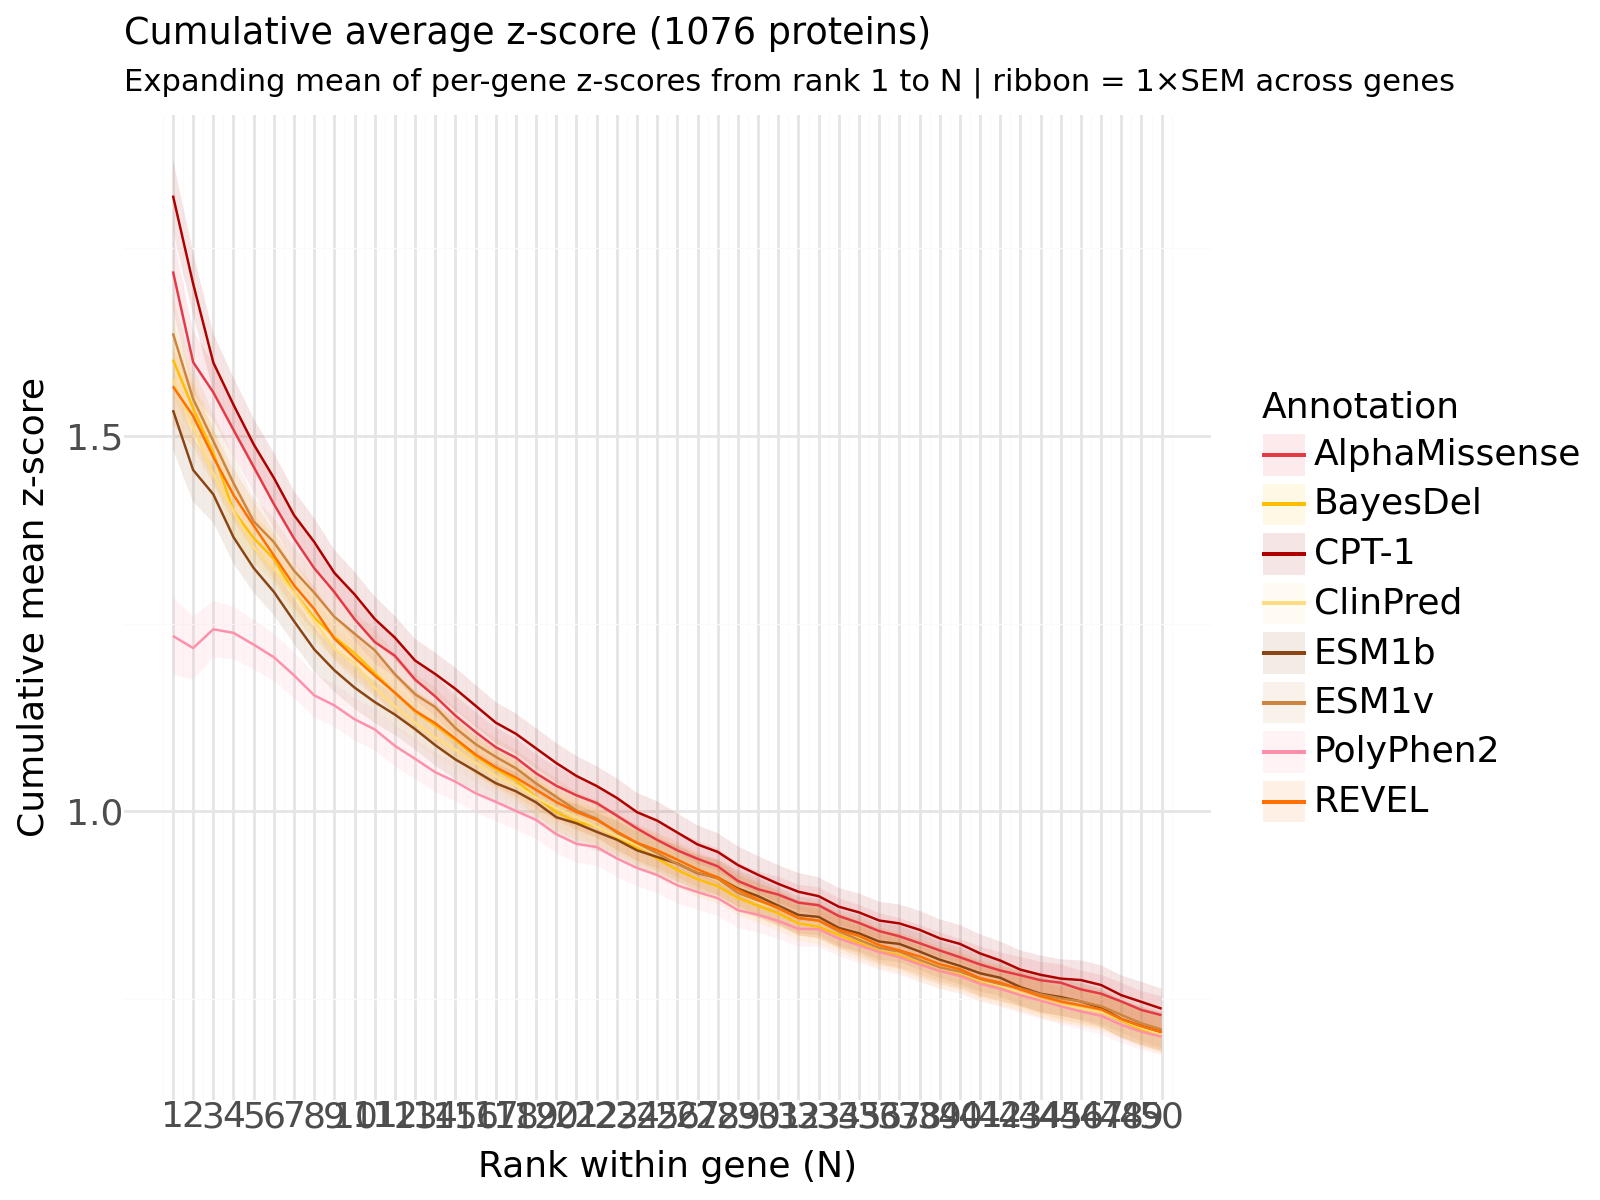

In [18]:
# Cumulative average z-score with proper per-gene SEM
# For each (annotation, region), compute cumulative mean up to rank N,
# then aggregate across genes to get mean and SEM at each N.
cum_genewise_stats = (
    ranked_zscores_genewise.lazy()
    .filter(pl.col('gene_rank') <= max_gene_rank)
    .sort(['annotation', 'region', 'gene_rank'])
    .with_columns(
        cum_mean_pheno=(
            pl.col('mean_pheno_value').cum_sum().over(['annotation', 'region'])
            / pl.col('gene_rank')
        )
    )
    .group_by(['annotation', 'gene_rank'])
    .agg(
        mean_cum_zscore=pl.col('cum_mean_pheno').mean(),
        std_cum_zscore =pl.col('cum_mean_pheno').std(),
        n_genes        =pl.col('region').n_unique(),
    )
    .with_columns(
        se_cum_zscore=pl.col('std_cum_zscore') / pl.col('n_genes').cast(pl.Float64).sqrt(),
    )
    .with_columns(
        ci_lower=pl.col('mean_cum_zscore') - ci_factor * pl.col('se_cum_zscore'),
        ci_upper=pl.col('mean_cum_zscore') + ci_factor * pl.col('se_cum_zscore'),
    )
    .join(anno_config_df.select(['annotation', 'label', 'color']).lazy(), on='annotation', how='left')
    .sort(['annotation', 'gene_rank'])
    .collect()
)

color_dict = dict(zip(cum_genewise_stats['label'], cum_genewise_stats['color']))

(
    ggplot(cum_genewise_stats, aes(x='gene_rank', y='mean_cum_zscore', color='label', fill='label'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper'), alpha=0.1, color='none')
    + geom_line()
    + scale_color_manual(values=color_dict)
    + scale_fill_manual(values=color_dict)
    + scale_x_continuous(breaks=range(1, max_gene_rank + 1))
    + labs(
        title=f"Cumulative average z-score ({olink_whitelist.shape[0]} proteins)",
        subtitle=f"Expanding mean of per-gene z-scores from rank 1 to N | ribbon = {ci_factor}×SEM across genes",
        x="Rank within gene (N)",
        y="Cumulative mean z-score",
        color="Annotation",
        fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)


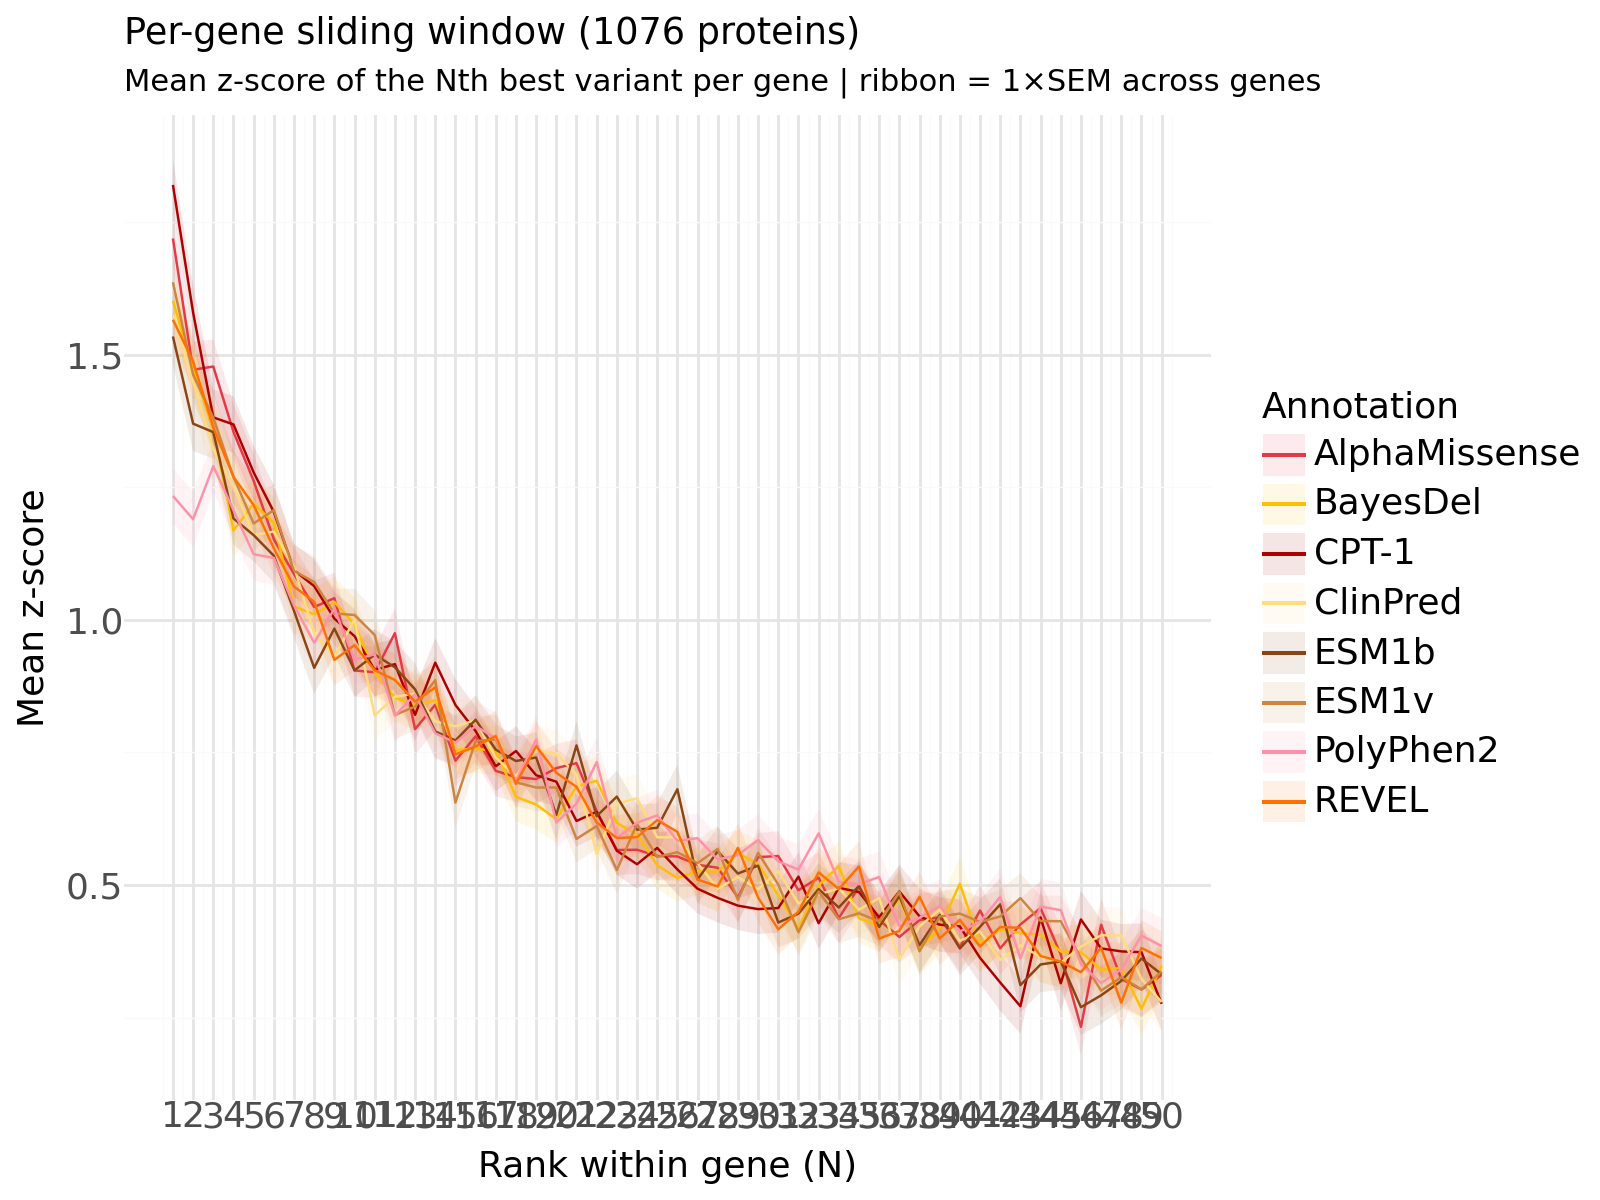

In [19]:
# For each annotation and rank N, take exactly the Nth variant per gene
# and average z-scores across genes. CI = 1.96 * SEM across genes.
genewise_stats = (
    ranked_zscores_genewise.lazy()
    .filter(pl.col('gene_rank') <= max_gene_rank)
    .group_by(['annotation', 'gene_rank'])
    .agg(
        mean_zscore = pl.col('mean_pheno_value').mean(),
        std_zscore  = pl.col('mean_pheno_value').std(),
        n_genes     = pl.col('region').n_unique(),
    )
    .with_columns(
        se_zscore = pl.col('std_zscore') / pl.col('n_genes').cast(pl.Float64).sqrt(),
    )
    .with_columns(
        ci_lower = pl.col('mean_zscore') - ci_factor * pl.col('se_zscore'),
        ci_upper = pl.col('mean_zscore') + ci_factor * pl.col('se_zscore'),
    )
    .join(anno_config_df.select(['annotation', 'label', 'color']).lazy(), on='annotation', how='left')
    .sort(['annotation', 'gene_rank'])
    .collect()
)

(
    ggplot(genewise_stats, aes(x='gene_rank', y='mean_zscore', color='label', fill='label'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper'), alpha=0.1, color='none')
    + geom_line()
    + scale_color_manual(values=color_dict)
    + scale_fill_manual(values=color_dict)
    + scale_x_continuous(breaks=range(1, max_gene_rank + 1))
    + labs(
        title=f"Per-gene sliding window ({olink_whitelist.shape[0]} proteins)",
        subtitle=f"Mean z-score of the Nth best variant per gene | ribbon = {ci_factor}×SEM across genes",
        x="Rank within gene (N)",
        y="Mean z-score",
        color="Annotation",
        fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)